In [6]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, scaler_X, scaler_y = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
833     49425.0
2170    40635.0
747     56355.0
2668    46140.0
1260    41370.0
         ...   
1238    36735.0
637     56160.0
736     49455.0
1657    62715.0
4161    43710.0
Name: time_to_next_ev_hr, Length: 2964, dtype: float64
      tide_deriv  form_fac  slip_size  high_t_evt  tide_height  time_since
833     0.017756  1.138125  -0.479608           0    -6.978077     52155.0
2170    0.010877  3.166799   1.571012           1    50.696344     88560.0
747     0.013680  2.683052  -0.909037           0   -60.108081     45795.0
2668   -0.236325  0.989993   0.992235           1    44.526863     76500.0
1260   -0.111785  2.935354   0.226041           1    87.247526     47310.0


In [ ]:
# CatBoost
from catboost import CatBoostRegressor

# Avoiding any modification to original data sets since it uses column names and datatypes
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

cat_features = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()

#Tuning CatBoost in Optuna using the same method as XGBoost
def objective_cat(trial):
  CatBoost = CatBoostRegressor(
      iterations = 100,
      learning_rate = trial.suggest_float("learning_rate",0.01,0.1,log=True),
      depth = trial.suggest_int("depth",2,8),
      loss_function = "RMSE",
      eval_metric = "RMSE",
      random_seed = 42,
      verbose=False,
      allow_writing_files=False,
      posterior_sampling=True,
      )

  CatBoost.fit(
      X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)
  predictions_cat = CatBoost.predict(X_val_cat)
  RMSE_cat = root_mean_squared_error(y_val, predictions_cat)
  return RMSE_cat

sampler = optuna.samplers.TPESampler(seed=42)  # Fix seed for reproducibility
optimization_cat = optuna.create_study(direction="minimize", sampler=sampler) #minimizing the above parameters
optimization_cat.optimize(objective_cat, n_trials=30) #keeping trails low for runtime and to prevent over-fitting noise

optimal_params_cat = optimization_cat.best_params
print("Optimal Parameters Cat:", optimal_params_cat)

#Running CatBoost with the optimal parameters
CatBoost = CatBoostRegressor(
    iterations = 100,
    **optimal_params_cat,
    loss_function = "RMSE",
    eval_metric = "RMSE",
    random_seed = 42,
    verbose=False,
    allow_writing_files=False
    )

CatBoost.fit(
    X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)

# Unscale predictions and test values back to original seconds
CatBoost_Prediction_scaled = CatBoost.predict(X_test_cat)
CatBoost_Prediction = scaler_y.inverse_transform(CatBoost_Prediction_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

CatBoost_RMSE = root_mean_squared_error(y_test_original, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost RMSE (seconds):", CatBoost_Error)

CatBoost MAE (seconds): 19262.01462325899
Sample0: True = 83970.00s, Predicted = 62077.66s, Error=21892.34s
Sample1: True = 87270.00s, Predicted = 41390.80s, Error=45879.20s
Sample2: True = 33150.00s, Predicted = 41536.56s, Error=8386.56s
Sample3: True = 63240.00s, Predicted = 59157.86s, Error=4082.14s
Sample4: True = 83475.00s, Predicted = 66324.82s, Error=17150.18s
Sample5: True = 30930.00s, Predicted = 37046.80s, Error=6116.80s
Sample6: True = 64215.00s, Predicted = 58507.02s, Error=5707.98s
Sample7: True = 80820.00s, Predicted = 61420.88s, Error=19399.12s
Sample8: True = 29430.00s, Predicted = 55782.98s, Error=26352.98s
Sample9: True = 57720.00s, Predicted = 57158.33s, Error=561.67s
Sample10: True = 86460.00s, Predicted = 59570.28s, Error=26889.72s
Sample11: True = 40245.00s, Predicted = 55070.87s, Error=14825.87s
Sample12: True = 48015.00s, Predicted = 56145.76s, Error=8130.76s
Sample13: True = 84210.00s, Predicted = 50375.23s, Error=33834.77s
Sample14: True = 51780.00s, Predicted

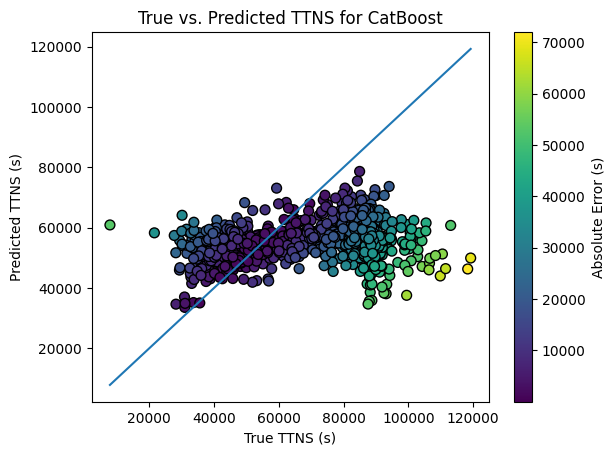

In [4]:
# CatBoost Analysis - values already unscaled from previous cell
y_test_secs = y_test_original
Cat_pred_secs = CatBoost_Prediction

absolute_error_secs_Cat = np.abs(Cat_pred_secs - y_test_secs)

MAE_seconds = np.mean(absolute_error_secs_Cat)
print("CatBoost MAE (seconds):", MAE_seconds)

#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, Cat_pred_secs, absolute_error_secs_Cat)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, Cat_pred_secs, c=absolute_error_secs_Cat, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for CatBoost")
plt.show()

Cat Boost Drivers: form_fac       0.098159
tide_height    0.070308
time_since     0.070121
tide_deriv     0.058719
slip_size      0.057718
high_t_evt     0.038115
dtype: float64


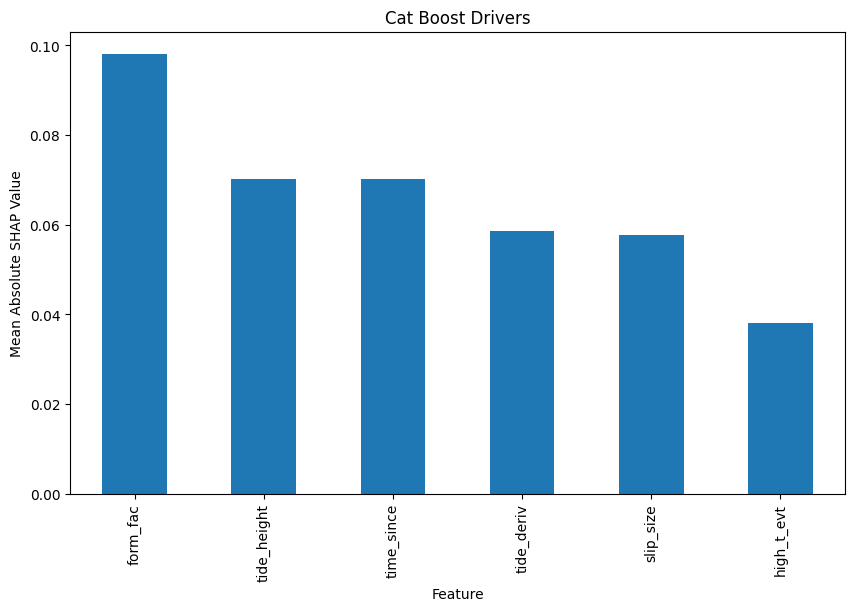

In [5]:
# Driving parameters for Cat

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_cat = shap.TreeExplainer(CatBoost, X_shap, feature_perturbation="interventional")

shap_values_cat = explainer_cat.shap_values(X_shap)#Doing the tree analysis on Cat uisng training data

Cat_imp = pd.Series(np.abs(shap_values_cat).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)#Analysis of driving parameters in Cat

print("Cat Boost Drivers:", Cat_imp)

# Creating a bar graph showing the driving parameters for CatBoost


plt.figure(figsize=(10, 6))
Cat_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Cat Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()